In [22]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

def fetch_weather_data():
    # 南昌市大致经纬度
    lat, lon = 28.68, 115.89
    # Open-Meteo Historical API URL (2024-2025)
    url = (
        f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}"
        f"&start_date=2024-01-01&end_date=2025-12-31"
        f"&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
        f"precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,"
        f"surface_pressure_mean,weather_code"
        f"&timezone=Asia%2FShanghai&wind_speed_unit=ms"
    )

    response = requests.get(url)
    data = response.json()

    df = pd.DataFrame(data['daily'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df.index.name = 'date'

    # 重命名列以符合实验要求
    df.rename(columns={
        'temperature_2m_max': 't2m_max',
        'temperature_2m_min': 't2m_min',
        'temperature_2m_mean': 't2m_mean',
        'precipitation_sum': 'precipitation_sum',
        'wind_speed_10m_max': 'windspeed_10m_max',
        'relative_humidity_2m_mean': 'relative_humidity_2m_mean',
        'surface_pressure_mean': 'surface_pressure_mean',
        'weather_code': 'weathercode'
    }, inplace=True)

    # 填补可能存在的缺失值
    df.fillna(method='ffill', inplace=True)
    return df

df = fetch_weather_data()
print("数据前5行：\n", df.head())

数据前5行：
             t2m_max  t2m_min  t2m_mean  precipitation_sum  windspeed_10m_max  \
date                                                                           
2024-01-01     12.2      4.3       7.6                0.0               5.40   
2024-01-02      8.8      3.8       6.1                8.7               4.64   
2024-01-03     11.9      0.4       5.8                0.0               2.35   
2024-01-04     11.9      1.9       6.5                0.0               2.51   
2024-01-05     15.3      5.3       9.8                0.0               2.50   

            relative_humidity_2m_mean  surface_pressure_mean  weathercode  
date                                                                       
2024-01-01                         67                 1022.4            3  
2024-01-02                         83                 1019.9           63  
2024-01-03                         83                 1024.3            2  
2024-01-04                         80              

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# 特征选择与标准化
features_cluster = ['t2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'windspeed_10m_max']
X_cluster = df[features_cluster].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

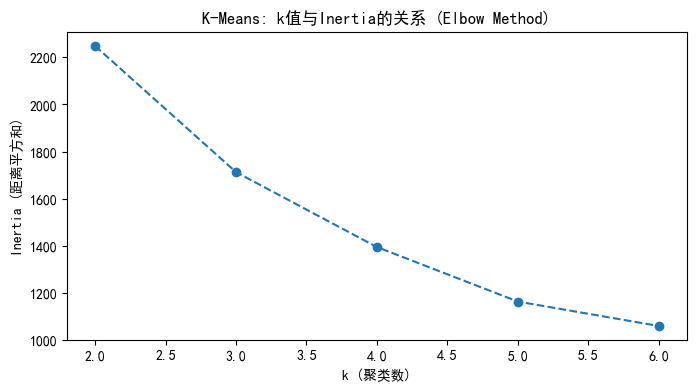


--- DBSCAN 参数搜索结果 ---
eps=0.3, min_samples=5 -> 聚类数量: 18, 噪声点数量: 512
eps=0.3, min_samples=10 -> 聚类数量: 2, 噪声点数量: 694
eps=0.4, min_samples=5 -> 聚类数量: 9, 噪声点数量: 317
eps=0.4, min_samples=10 -> 聚类数量: 4, 噪声点数量: 508
eps=0.5, min_samples=5 -> 聚类数量: 3, 噪声点数量: 182
eps=0.5, min_samples=10 -> 聚类数量: 2, 噪声点数量: 337
eps=0.6, min_samples=5 -> 聚类数量: 2, 噪声点数量: 109
eps=0.6, min_samples=10 -> 聚类数量: 1, 噪声点数量: 213
eps=0.7, min_samples=5 -> 聚类数量: 2, 噪声点数量: 64
eps=0.7, min_samples=10 -> 聚类数量: 1, 噪声点数量: 107
eps=0.8, min_samples=5 -> 聚类数量: 2, 噪声点数量: 43
eps=0.8, min_samples=10 -> 聚类数量: 1, 噪声点数量: 75
eps=0.9, min_samples=5 -> 聚类数量: 1, 噪声点数量: 31
eps=0.9, min_samples=10 -> 聚类数量: 1, 噪声点数量: 52


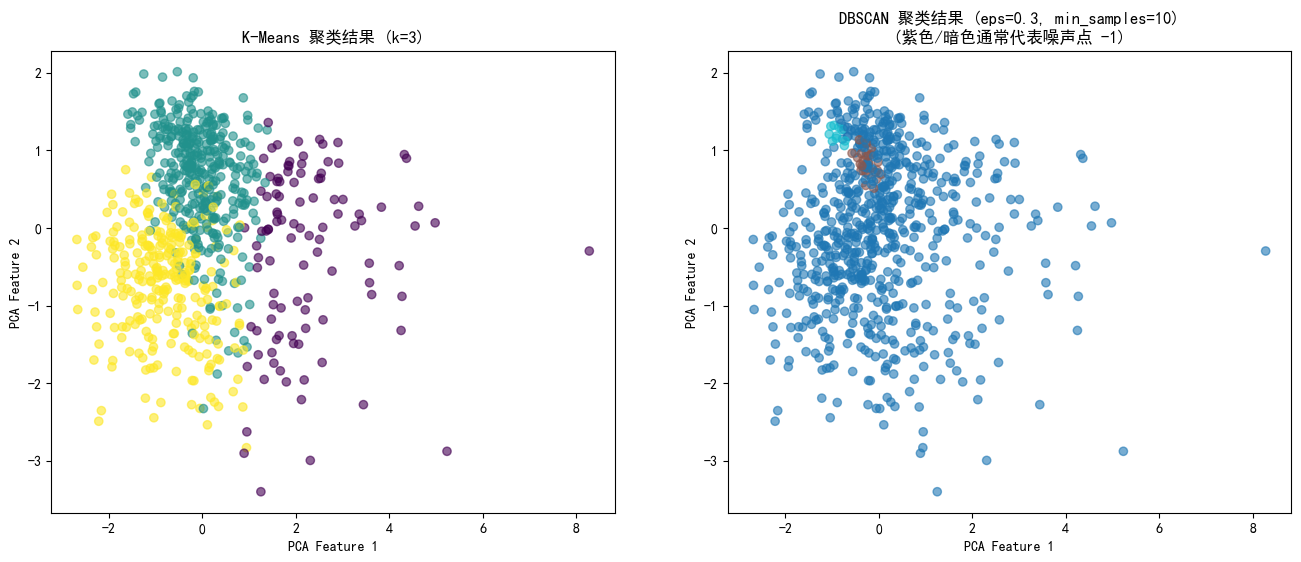

In [24]:
# --- 2. K-Means: 寻找最佳 k 值 ---
inertias = []
k_values = [2, 3, 4, 5, 6]
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, marker='o', linestyle='--')
plt.title('K-Means: k值与Inertia的关系 (Elbow Method)')
plt.xlabel('k (聚类数)')
plt.ylabel('Inertia (距离平方和)')
plt.show()

# 假设通过观察拐点，选择最佳 k=3 (根据实际图形调整)
best_k = 3
kmeans_best = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans_best.fit_predict(X_scaled)

# --- 3. DBSCAN 算法参数搜索 ---
print("\n--- DBSCAN 参数搜索结果 ---")
eps_values = np.arange(0.3, 0.9, 0.1)
min_samples_values = [5, 10]

best_dbscan_labels = None
best_eps, best_min_samples = 0.5, 10 # 预设一个较优参数用于画图

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps={eps:.1f}, min_samples={min_samples} -> 聚类数量: {n_clusters}, 噪声点数量: {n_noise}")

        # 保存一组较优参数的标签用于后续可视化 (例如分类数在 2-5 之间)
        if 2 <= n_clusters <= 5 and best_dbscan_labels is None:
            best_dbscan_labels = labels
            best_eps, best_min_samples = eps, min_samples

# 如果没有匹配的较优参数，强制使用预设运行一次
if best_dbscan_labels is None:
    best_dbscan_labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(X_scaled)

# --- 4. 可视化对比 ---
# 使用 PCA 降维到 2D 以便进行散点图可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图: K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means 聚类结果 (k={best_k})')
axes[0].set_xlabel('PCA Feature 1')
axes[0].set_ylabel('PCA Feature 2')

# 右图: DBSCAN (区分核心点、边界点与噪声点)
# DBSCAN 中，标签为 -1 的是噪声点
cmap = plt.cm.get_cmap('tab10', len(set(best_dbscan_labels)))
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_labels, cmap=cmap, alpha=0.6)
axes[1].set_title(f'DBSCAN 聚类结果 (eps={best_eps:.1f}, min_samples={best_min_samples})\n(紫色/暗色通常代表噪声点 -1)')
axes[1].set_xlabel('PCA Feature 1')
axes[1].set_ylabel('PCA Feature 2')

plt.show()

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import lightgbm as lgb

df_reg = df.copy()

# 目标变量：未来一天（明天）的最大风速
df_reg['target_windspeed'] = df_reg['windspeed_10m_max'].shift(-1)

# 基础特征 (Today) 已经存在，重命名映射关系以匹配语境：
# temperature_today -> t2m_mean
# humidity_today -> relative_humidity_2m_mean
# 等等...

# 滞后特征 (过去3天)
for col in ['t2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'precipitation_sum', 'windspeed_10m_max']:
    for i in range(1, 4):
        df_reg[f'{col}_lag_{i}'] = df_reg[col].shift(i)

# 滚动统计特征
df_reg['temp_roll_mean_3d'] = df_reg['t2m_mean'].rolling(window=3).mean()
df_reg['precip_roll_sum_7d'] = df_reg['precipitation_sum'].rolling(window=7).sum()
df_reg['wind_roll_max_5d'] = df_reg['windspeed_10m_max'].rolling(window=5).max()

# 衍生特征
# 温度变化率: (今日温度 - 昨日温度) / 昨日温度 (加入极小值防除0)
df_reg['temp_change_rate'] = (df_reg['t2m_mean'] - df_reg['t2m_mean'].shift(1)) / (df_reg['t2m_mean'].shift(1) + 1e-5)
# 气压梯度: 今日气压 - 昨日气压
df_reg['pressure_gradient'] = df_reg['surface_pressure_mean'] - df_reg['surface_pressure_mean'].shift(1)

# 删除因为 shift 和 rolling 产生的 NaN 缺失值
df_reg.dropna(inplace=True)

# 划分特征和目标
features_reg = [c for c in df_reg.columns if c not in ['target_windspeed', 'weathercode', 't2m_max', 't2m_min']]
X = df_reg[features_reg]
y = df_reg['target_windspeed']

# 按照年份划分数据集
train_mask = X.index.year == 2024
test_mask = X.index.year == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# 回归模型同样需要对特征进行标准化
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

线性回归 - MSE: 1.8846, R方: 0.2259

--- 回归模型性能对比 ---
Linear Regression    - MSE: 1.8846, R方: 0.2259


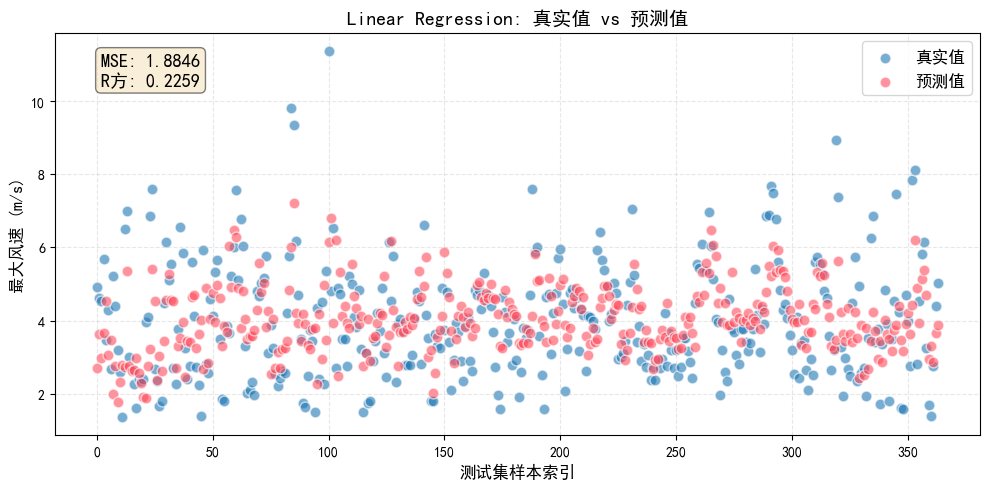

KNN                  - MSE: 2.6466, R方: -0.0872


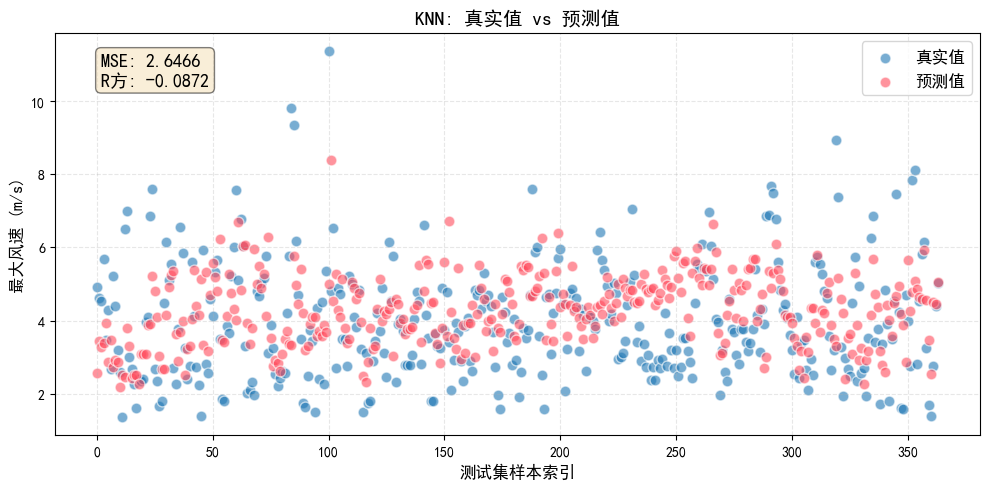

SVR                  - MSE: 1.8284, R方: 0.2489


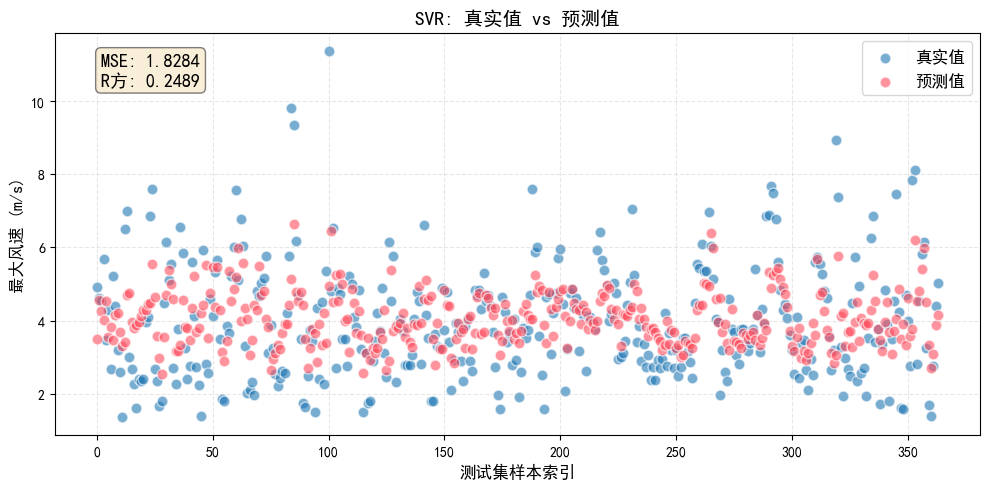

LightGBM             - MSE: 2.3922, R方: 0.0173


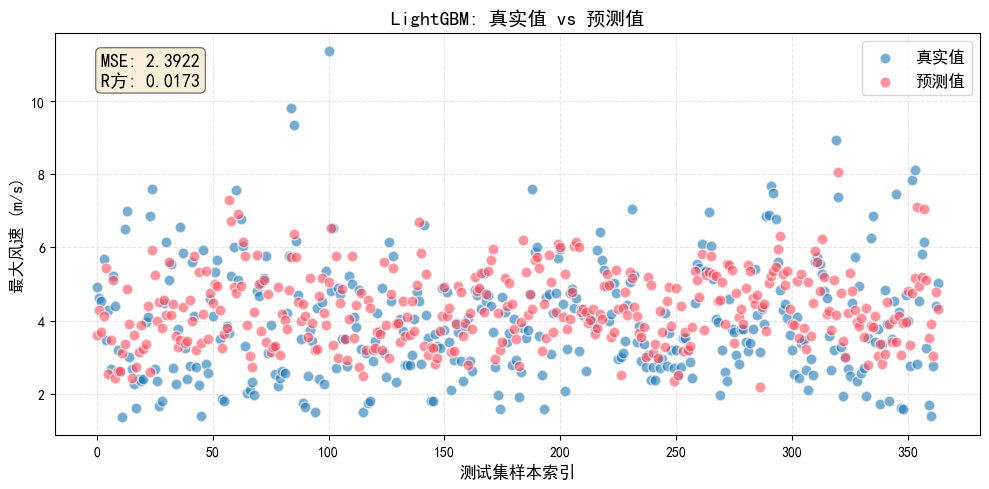

In [38]:
# --- 1. 线性回归 (保持原有代码不变) ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"线性回归 - MSE: {mse_lr:.4f}, R方: {r2_lr:.4f}")

# --- 2. 回归模型对比 & 绘图 ---
models = {
    'Linear Regression': lr_model,
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf'),
    'LightGBM': lgb.LGBMRegressor(
        num_leaves=15,
        min_child_samples=5,
        verbose=-1,
        random_state=42
    )
}

print("\n--- 回归模型性能对比 ---")
for name, model in models.items():
    if name != 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = y_pred_lr

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name:20s} - MSE: {mse:.4f}, R方: {r2:.4f}")

    # ====================== 绘图部分 ======================
    plt.figure(figsize=(10, 5))
    ax = plt.gca() # 获取当前坐标轴句柄

    # 绘制真实值 (蓝色) 和 预测值 (红色) 的散点
    plt.scatter(range(len(y_test)), y_test,
                alpha=0.6, s=60, color='#1f77b4', label='真实值', edgecolors='white')
    plt.scatter(range(len(y_test)), y_pred,
                alpha=0.6, s=60, color='#ff4b5c', label='预测值', edgecolors='white')

    # ====================== 新增：左上角标注指标 ======================
    # 使用 axes 相对坐标 (0-1)，确保文字位置固定在左上角
    text_str = f"MSE: {mse:.4f}\nR方: {r2:.4f}"
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.title(f'{name}: 真实值 vs 预测值', fontsize=14)
    plt.xlabel('测试集样本索引', fontsize=12)
    plt.ylabel('最大风速 (m/s)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

线性回归 - MSE: 1.8846, R方: 0.2259

--- 回归模型性能对比 ---
Linear Regression    - MSE: 1.8846, R方: 0.2259
KNN                  - MSE: 2.6466, R方: -0.0872
SVR                  - MSE: 1.8284, R方: 0.2489
LightGBM             - MSE: 2.3922, R方: 0.0173


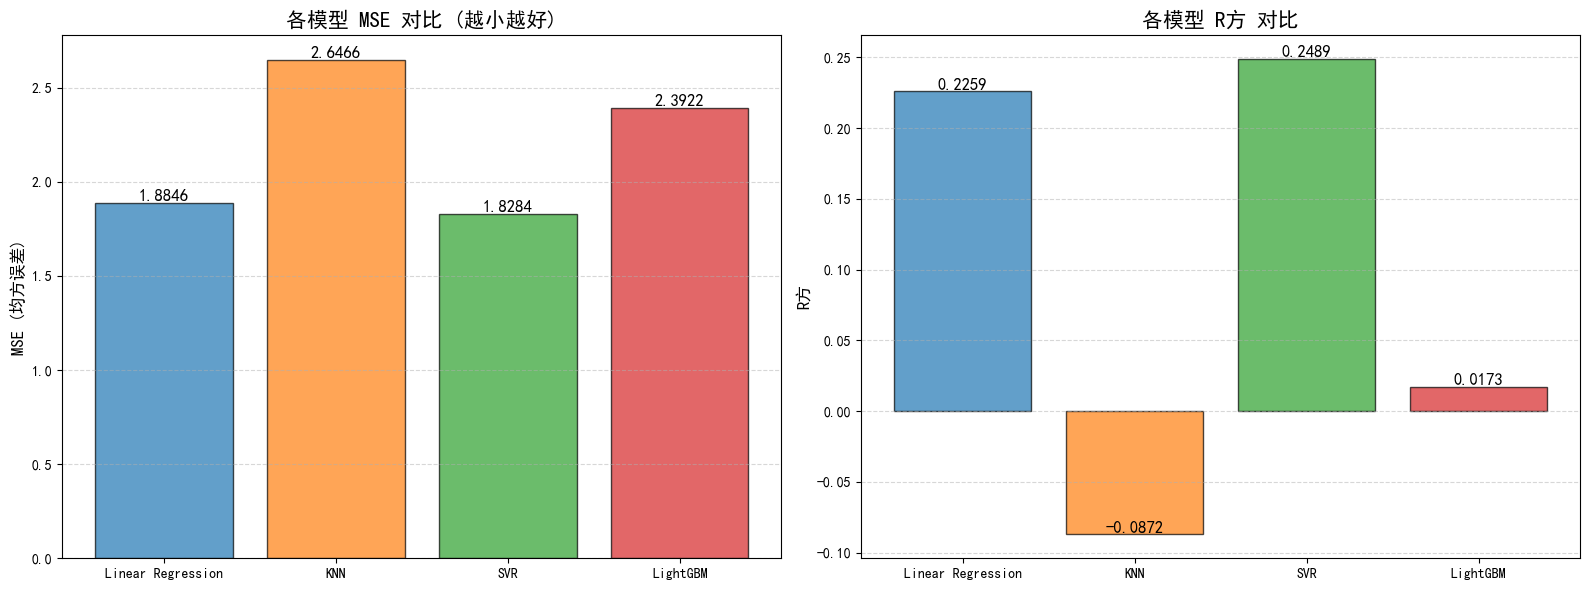

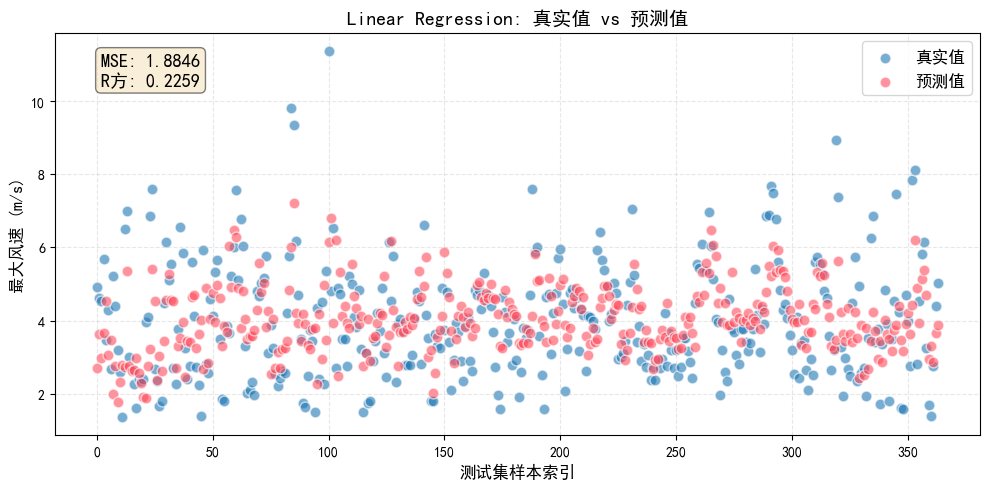

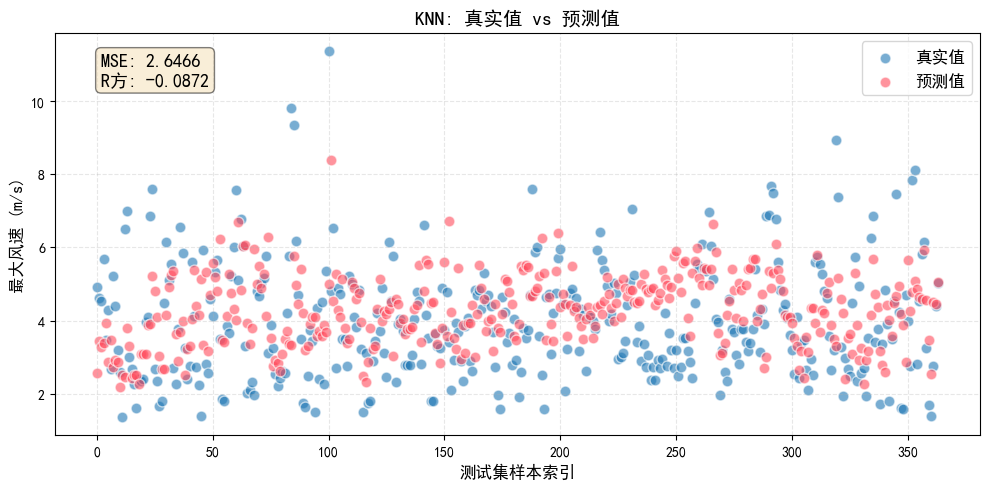

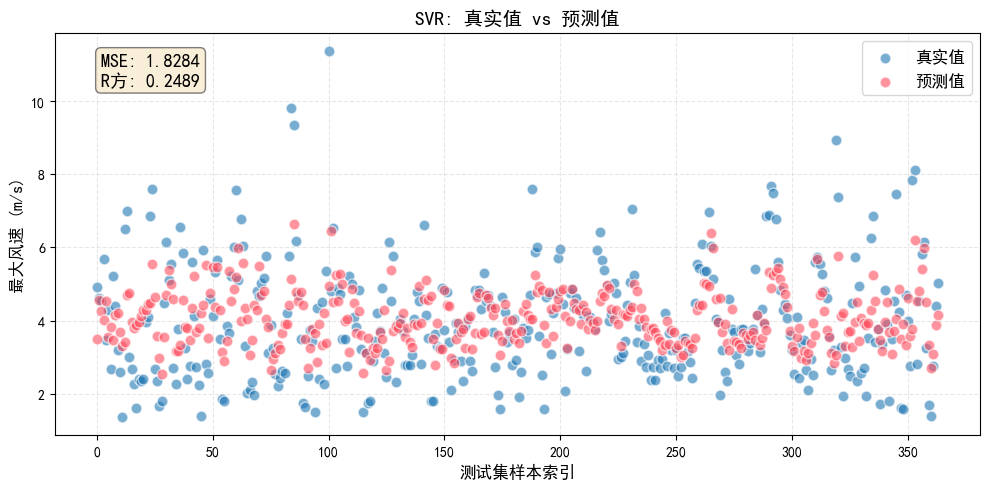

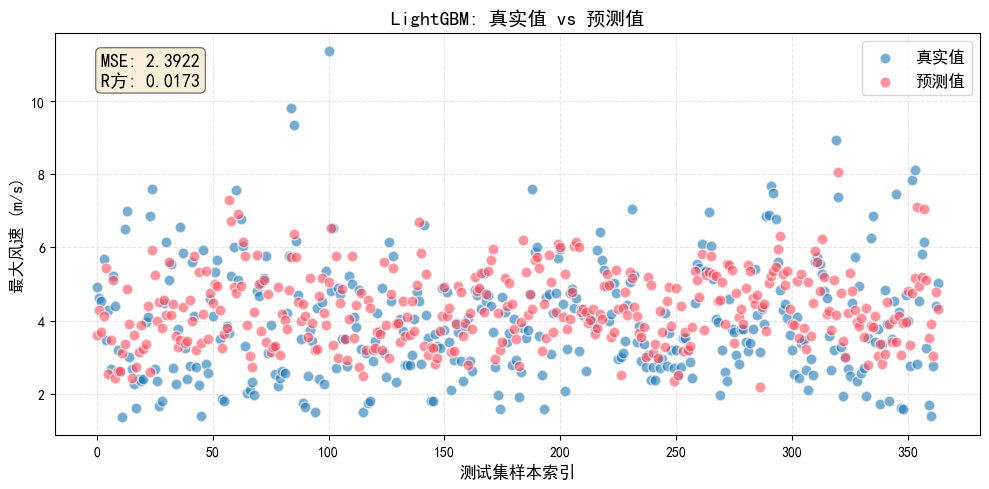

In [44]:
# --- 1. 线性回归 (保持原有代码不变) ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"线性回归 - MSE: {mse_lr:.4f}, R方: {r2_lr:.4f}")

# --- 2. 回归模型对比 (先收集数据) ---
models = {
    'Linear Regression': lr_model,
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(kernel='rbf'),
    'LightGBM': lgb.LGBMRegressor(
        num_leaves=15,
        min_child_samples=5,
        verbose=-1,
        random_state=42
    )
}

# 初始化列表用于存储绘图数据
model_names = []
mse_scores = []
r2_scores = []
predictions = {} # 用于存每个模型的预测值，方便后面画散点图

print("\n--- 回归模型性能对比 ---")
for name, model in models.items():
    if name != 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = y_pred_lr

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name:20s} - MSE: {mse:.4f}, R方: {r2:.4f}")

    # 收集数据
    model_names.append(name)
    mse_scores.append(mse)
    r2_scores.append(r2)
    predictions[name] = y_pred

# ====================== 新增：MSE & R方 对比可视化 ======================

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 颜色设置
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- 左图：MSE对比 (越小越好) ---
bars1 = ax1.bar(model_names, mse_scores, color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('各模型 MSE 对比 (越小越好)', fontsize=15, fontweight='bold')
ax1.set_ylabel('MSE (均方误差)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# 在柱子上标注数值
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- 右图：R方对比 (越大越好) ---
bars2 = ax2.bar(model_names, r2_scores, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('各模型 R方 对比', fontsize=15, fontweight='bold')
ax2.set_ylabel('R方', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
# 在柱子上标注数值
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ====================== 新增：批量绘制散点图 (可选，如果你还想看每个模型的散点图) ======================
for name in model_names:
    y_pred = predictions[name]

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    plt.scatter(range(len(y_test)), y_test,
                alpha=0.6, s=60, color='#1f77b4', label='真实值', edgecolors='white')
    plt.scatter(range(len(y_test)), y_pred,
                alpha=0.6, s=60, color='#ff4b5c', label='预测值', edgecolors='white')

    # 找到当前模型的指标
    idx = model_names.index(name)
    text_str = f"MSE: {mse_scores[idx]:.4f}\nR方: {r2_scores[idx]:.4f}"
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.title(f'{name}: 真实值 vs 预测值', fontsize=14)
    plt.xlabel('测试集样本索引', fontsize=12)
    plt.ylabel('最大风速 (m/s)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df_clf = df_reg.copy()

# 标签工程：明天风速 < 8 且 明天降水量 < 3
condition_wind = df['windspeed_10m_max'].shift(-1) < 8
condition_precip = df['precipitation_sum'].shift(-1) < 3
# 考虑到我们在回归部分已经去除了含有NaN的行，我们需要对齐索引
df_clf['flight_suitable'] = ((condition_wind) & (condition_precip)).astype(int).loc[df_clf.index]

y_clf = df_clf['flight_suitable']

# 使用与回归任务相同的特征集 X
y_clf_train = y_clf[train_mask]
y_clf_test = y_clf[test_mask]

# --- 定义评估函数 ---
def evaluate_clf(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"{model_name:18s} | 准确率: {acc:.4f} | 精确率: {prec:.4f} | 召回率: {rec:.4f} | F1: {f1:.4f}")

print("\n--- 分类模型性能对比 ---")

# 1. 逻辑回归
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_clf_train)
y_pred_log = log_reg.predict(X_test_scaled)
evaluate_clf("Logistic Regression", y_clf_test, y_pred_log)

# 2. 决策树 (限制最大深度为3防止过拟合)
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
# 决策树可以不需要特征缩放，但用 scaled 也不影响
tree_clf.fit(X_train_scaled, y_clf_train)
y_pred_tree = tree_clf.predict(X_test_scaled)
evaluate_clf("Decision Tree", y_clf_test, y_pred_tree)

# 3. 随机森林
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_clf_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
evaluate_clf("Random Forest", y_clf_test, y_pred_rf)


--- 分类模型性能对比 ---
Logistic Regression | 准确率: 0.7582 | 精确率: 0.8231 | 召回率: 0.8705 | F1: 0.8462
Decision Tree      | 准确率: 0.7033 | 精确率: 0.7972 | 召回率: 0.8201 | F1: 0.8085
Random Forest      | 准确率: 0.6978 | 精确率: 0.8111 | 召回率: 0.7878 | F1: 0.7993


In [28]:
# 获取测试集中最后一天的特征作为“今天”的输入数据
latest_features = X_test_scaled[-1].reshape(1, -1)
latest_date = X_test.index[-1].strftime('%Y-%m-%d')

# 这里我们使用随机森林作为最终判定模型（通常表现最稳健）
prediction = rf_clf.predict(latest_features)[0]
decision = "适合飞行" if prediction == 1 else "不适合飞行"

print(f"\n--- 无人机飞行判断 ---")
print(f"基于 {latest_date} 及过去的历史数据预测：")
print(f"模型判断明日气象条件：>> {decision} <<")


--- 无人机飞行判断 ---
基于 2025-12-30 及过去的历史数据预测：
模型判断明日气象条件：>> 适合飞行 <<


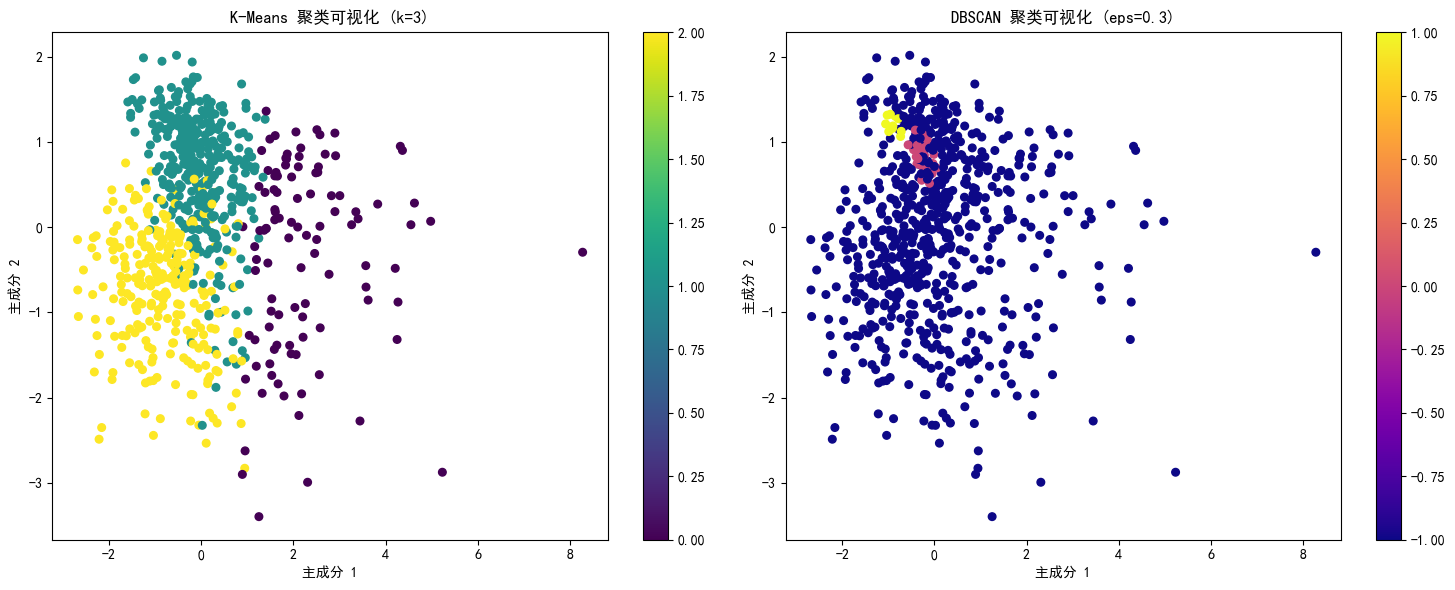

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 使用 PCA 将 4 维特征降至 2 维以便绘图 [cite: 12]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. K-Means 可视化 (假设最佳 k=3) [cite: 14, 18]
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
ax1.set_title(f'K-Means 聚类可视化 (k={best_k})')
ax1.set_xlabel('主成分 1')
ax1.set_ylabel('主成分 2')
plt.colorbar(scatter1, ax=ax1)

# 2. DBSCAN 可视化 [cite: 16, 18]
# 区分噪声点 (-1) 和常规簇
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_labels, cmap='plasma', s=30)
ax2.set_title(f'DBSCAN 聚类可视化 (eps={best_eps})')
ax2.set_xlabel('主成分 1')
ax2.set_ylabel('主成分 2')
plt.colorbar(scatter2, ax=ax2)

plt.tight_layout()
plt.show()

In [12]:
# 假设你已经计算好了各个模型的 mse_list 和 r2_list
model_names = ['Linear', 'KNN', 'SVR', 'LightGBM']
mse_values = [mse_lr, mse_knn, mse_svr, mse_lgbm] # 对应之前计算的结果
r2_values = [r2_lr, r2_knn, r2_svr, r2_lgbm]

fig, ax_mse = plt.subplots(figsize=(10, 5))

# 绘制 MSE 柱状图
ax_mse.bar(model_names, mse_values, color='skyblue', label='MSE (越低越好)')
ax_mse.set_ylabel('均方误差 (MSE)')
ax_mse.set_title('各回归模型性能对比 (测试集)')

# 添加 R2 折线图在右侧纵坐标
ax_r2 = ax_mse.twinx()
ax_r2.plot(model_names, r2_values, color='red', marker='o', linewidth=2, label='R² (越高越好)')
ax_r2.set_ylabel('R² 分数')
ax_r2.set_ylim(0, 1) # R2 通常在 0-1 之间

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax_mse.transAxes)
plt.show()

NameError: name 'mse_knn' is not defined

In [13]:
metrics_data = {
    '指标': ['准确率', '精确率', '召回率', 'F1-Score'],
    '逻辑回归': [acc_log, prec_log, rec_log, f1_log],
    '决策树': [acc_tree, prec_tree, rec_tree, f1_tree],
    '随机森林': [acc_rf, prec_rf, rec_rf, f1_rf]
}

df_metrics = pd.DataFrame(metrics_data).set_index('指标')

# 绘制多组柱状图
df_metrics.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('各分类模型评估指标对比')
plt.ylabel('分数')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

NameError: name 'acc_log' is not defined